<a href="https://colab.research.google.com/github/psallo/python_test/blob/master/%EB%86%8D%EA%B5%AC%EC%84%A0%EC%88%98_%ED%8F%AC%EC%A7%80%EC%85%98_%EC%98%88%EC%B8%A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 주요 라이브러리 import
import warnings
warnings.filterwarnings(action='ignore')
import time
from IPython.display import Image
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import *
from sklearn.metrics import roc_curve, roc_auc_score

from matplotlib import rc, font_manager
import matplotlib.font_manager as fm
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder

### Google Drive 마운트

Google Drive에서 파일을 로드하려면 먼저 다음 코드를 실행하여 Drive를 Colab 환경에 마운트해야 합니다. 이 과정에서 Google 계정 인증이 필요할 수 있습니다.

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


Drive가 성공적으로 마운트되면 `/content/gdrive/MyDrive/` 경로를 통해 Drive 파일에 접근할 수 있습니다. 이제 원하는 파일의 정확한 경로를 찾아 `pd.read_csv()` 또는 다른 `pd.read_` 함수를 사용하여 데이터를 로드할 수 있습니다. 예를 들어:

In [3]:
# 예시: Google Drive의 'My_Folder' 안에 있는 'my_data.csv' 파일을 로드
# df = pd.read_csv('/content/gdrive/MyDrive/My_Folder/my_data.csv')
# display(df.head())

In [4]:
df = pd.read_csv('/content/gdrive/MyDrive/AICC(개인)/python/basketball_stat.csv', encoding='utf-8')
df.head()

,Player,Pos,3P,2P,TRB,AST,STL,BLK
0,Alex Abrines,SG,1.4,0.6,1.3,0.6,0.5,0.1
1,Steven Adams,C,0.0,4.7,7.7,1.1,1.1,1.0
2,Alexis Ajinca,C,0.0,2.3,4.5,0.3,0.5,0.6
3,Chris Andersen,C,0.0,0.8,2.6,0.4,0.4,0.6
4,Will Barton,SG,1.5,3.5,4.3,3.4,0.8,0.5


Text(0.5, 1.0, 'STL and 2P')

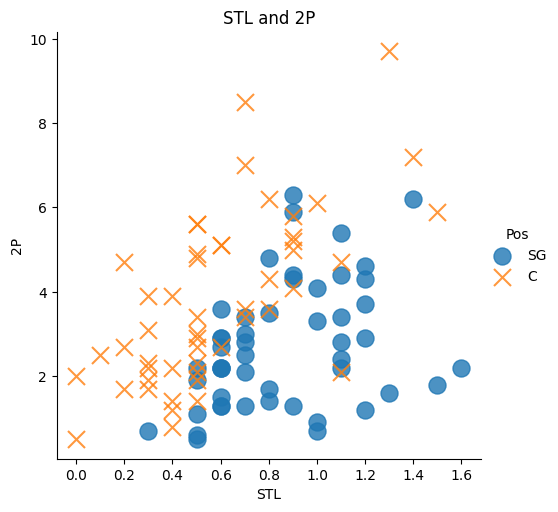

In [6]:
sns.lmplot(x='STL', y='2P', data=df,
               fit_reg=False,
               scatter_kws={'s' : 150},
               markers=['o', 'x'],
               hue = 'Pos'
          )
plt.title('STL and 2P')

Text(0.5, 1.0, 'AST and 2P')

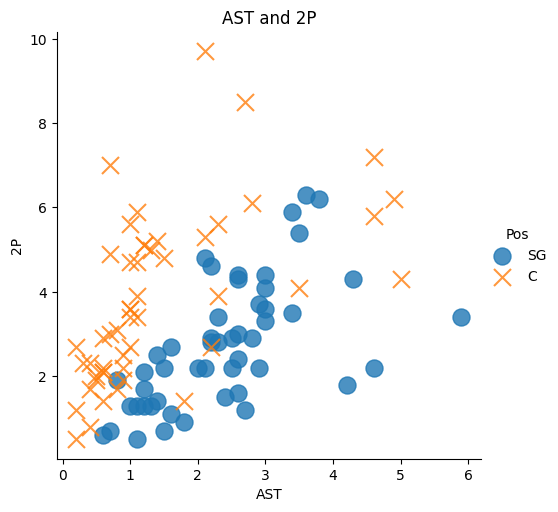

In [7]:
sns.lmplot(x='AST', y='2P', data=df, fit_reg=False,
               scatter_kws={'s' : 150},
               markers=['o', 'x'],
               hue = 'Pos'
          )
plt.title('AST and 2P')

Text(0.5, 1.0, '3P and BLK')

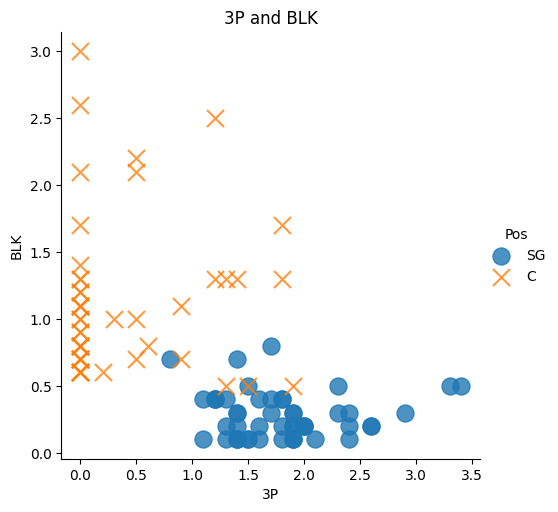

In [8]:
sns.lmplot(x='3P', y='BLK', data=df, fit_reg=False,
               scatter_kws={'s' : 150},
               markers=['o', 'x'],
               hue = 'Pos'
          )
plt.title('3P and BLK')

Text(0.5, 1.0, '3P and TRB')

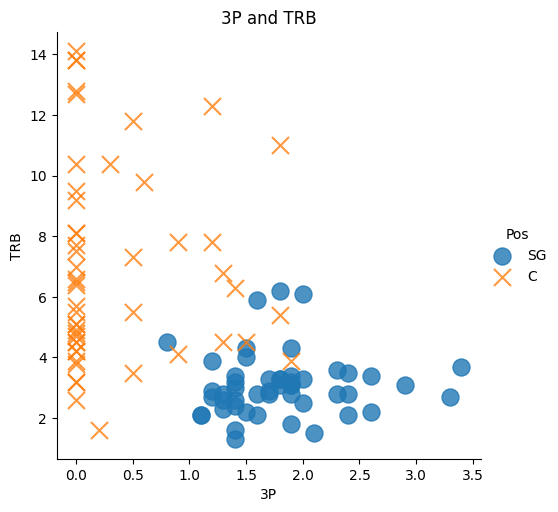

In [9]:
sns.lmplot(x='3P', y='TRB', data=df, fit_reg=False,
               scatter_kws={'s' : 150},
               markers=['o', 'x'],
               hue = 'Pos'
          )
plt.title('3P and TRB')

In [10]:
df.columns

Index(['Player', 'Pos', '3P', '2P', 'TRB', 'AST', 'STL', 'BLK'], dtype='object')

In [11]:
df.drop(['2P',  'AST', 'STL'], axis=1, inplace=True)

In [12]:
df.columns


Index(['Player', 'Pos', '3P', 'TRB', 'BLK'], dtype='object')

In [13]:
df

,Player,Pos,3P,TRB,BLK
0,Alex Abrines,SG,1.4,1.3,0.1
1,Steven Adams,C,0.0,7.7,1.0
2,Alexis Ajinca,C,0.0,4.5,0.6
3,Chris Andersen,C,0.0,2.6,0.6
4,Will Barton,SG,1.5,4.3,0.5
...,...,...,...,...,...
95,Nikola Vucevic,C,0.3,10.4,1.0
96,Dwyane Wade,SG,0.8,4.5,0.7
97,Dion Waiters,SG,1.8,3.3,0.4
98,Hassan Whiteside,C,0.0,14.1,2.1


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
                                                    df.iloc[:, 2:], #문제(설명변수 3개, 인덱스 2~끝),
                                                    df.iloc[:, 1], #정답(종속변수 1개, target, 인덱스 1)
                                                    test_size=0.2,  #테스트 비율
                                                    random_state=42#랜덤 시드값
)

In [15]:
df.shape

(100, 5)

In [16]:
X_train.shape, y_train.shape

((80, 3), (80,))

In [17]:
X_test.shape, y_test.shape

((20, 3), (20,))

In [18]:
X_train.index

Index([55, 88, 26, 42, 69, 15, 40, 96,  9, 72, 11, 47, 85, 28, 93,  5, 66, 65,
       35, 16, 49, 34,  7, 95, 27, 19, 81, 25, 62, 13, 24,  3, 17, 38,  8, 78,
        6, 64, 36, 89, 56, 99, 54, 43, 50, 67, 46, 68, 61, 97, 79, 41, 58, 48,
       98, 57, 75, 32, 94, 59, 63, 84, 37, 29,  1, 52, 21,  2, 23, 87, 91, 74,
       86, 82, 20, 60, 71, 14, 92, 51],
      dtype='int64')

In [19]:
X_test.index

Index([83, 53, 70, 45, 44, 39, 22, 80, 10, 0, 18, 30, 73, 33, 90, 4, 76, 77,
       12, 31],
      dtype='int64')

In [20]:
## 모델 선정 => cross-validation(교차검증)
## knn, svm, decison tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [21]:
knn = KNeighborsClassifier()
svm = SVC()
dt = DecisionTreeClassifier()
model_list = [knn, svm, dt]

In [22]:
model_list

[KNeighborsClassifier(), SVC(), DecisionTreeClassifier()]

In [23]:
scores = cross_val_score(knn, X_train, y_train, cv=5)
scores

array([0.9375, 0.8125, 0.8125, 0.875 , 1.    ])

In [25]:
np.mean(scores)

np.float64(0.8875)

In [28]:
def print_cv(model, train, test, k):
    scores = cross_val_score(model, train, test, cv = k)
    print(scores)
    mean_scores = np.mean(scores)
    print(mean_scores)
    return scores, mean_scores

In [30]:
mean_sc_list = []
for model in model_list:
    sc, mean_sc = print_cv(model, X_train, y_train, 5)
    print(sc, mean_sc)
    mean_sc_list.append(mean_sc)
    print('------------------------------------------------------')

[0.9375 0.8125 0.8125 0.875  1.    ]
0.8875
[0.9375 0.8125 0.8125 0.875  1.    ] 0.8875
------------------------------------------------------
[0.875  0.875  0.8125 0.9375 1.    ]
0.9
[0.875  0.875  0.8125 0.9375 1.    ] 0.9
------------------------------------------------------
[0.9375 1.     0.875  0.9375 1.    ]
0.95
[0.9375 1.     0.875  0.9375 1.    ] 0.95
------------------------------------------------------


In [31]:
mean_sc_list

[np.float64(0.8875), np.float64(0.9), np.float64(0.95)]

(array([1., 0., 1., 0., 0., 0., 0., 0., 0., 1.]),
 array([0.8875 , 0.89375, 0.9    , 0.90625, 0.9125 , 0.91875, 0.925  ,
        0.93125, 0.9375 , 0.94375, 0.95   ]),
 <BarContainer object of 10 artists>)

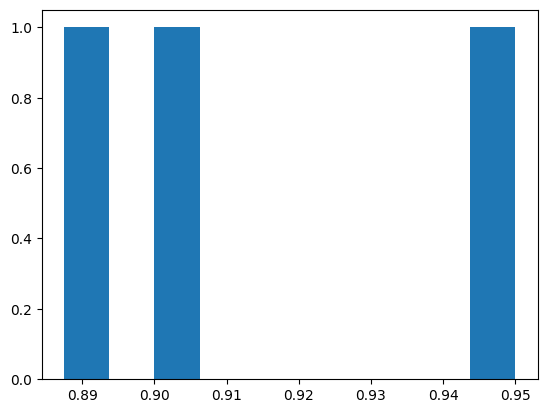

In [32]:
plt.hist(mean_sc_list)

In [39]:
params = { #하이퍼파라메터 설정으로 가질 수 있는 모든 경우의 수=> 4 * 3 * 2: 24개의 경우의 수
    'max_depth': [3, 5, 7, 10], #key : 하이퍼파라메터명, values는 list타입이어야 함.
    'random_state': [1, 3, 5],
    'criterion' : ['gini', 'entropy'] #혼란스러운 정도(분류의 정도)를 계산하는 기준
}

In [40]:
def grid_search(model, params, k):
    gs_model = GridSearchCV(model, params, cv=k)
    ## gs_model는 최적의 파라메터가 적용된 모델의 객체!
    gs_model.fit(X_train, y_train)
    print(gs_model.best_estimator_) ## 최적의 파라메터가 적용된 모델 객체
    print(gs_model.best_score_) ## 최적의 파라메터가 적용된 모델로 학습한 정확도 결과(accuracy)
    print(gs_model.best_params_) ## 그리드 서치를 통해 찾은 최적의 파라메터
    print(gs_model) ## grid_search 객체

In [41]:
grid_search(dt, params, 5) #grid_search의 모든 경우의 수는 24 * 5

DecisionTreeClassifier(max_depth=3, random_state=1)
0.95
{'criterion': 'gini', 'max_depth': 3, 'random_state': 1}
GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10],
                         'random_state': [1, 3, 5]})


In [42]:
dt_gs = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=1)
dt_gs.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=1)

In [43]:
predict_result = None
def test_validation(model, X_test, y_test):
    global predict_result
    predict_result = model.predict(X_test)
    print(predict_result)
    acc = accuracy_score(y_test, predict_result )
    print('accuracy >> ', acc)
    cf = confusion_matrix(y_test, predict_result)
    # 실제(c)--> 예측(c, sg), 실제(sg)--> 예측(sg, c),
    # 이진분류(binary classification)인 경우에는
    # 예측할 수 있는 경우의 수는 4가지!
    # 4가지를 표형태로 정리해주는 것이 confusion_matrix
    # 첫번째 행/열은 c, 두번째 행/열은 sg, abc순으로 행/열이 결정!
    print('confusion matrix >> \n', cf)
    ## confusion matrix는 binary classfication인 경우에는 보기가 괜찮으나,
    ## multi class classification인 경우에는 보기가 힘들다.
    ## confusion matrix를 가독성 좋게 볼 수 있는 것이 classification_report
    c_report = classification_report(y_test, predict_result)
    print('classification report >> \n', c_report)

In [44]:
test_validation(dt_gs, X_test, y_test)


['C' 'C' 'SG' 'SG' 'C' 'SG' 'SG' 'SG' 'C' 'SG' 'C' 'C' 'SG' 'C' 'C' 'C'
 'SG' 'C' 'SG' 'C']
accuracy >>  0.95
confusion matrix >> 
 [[10  0]
 [ 1  9]]
classification report >> 
               precision    recall  f1-score   support

           C       0.91      1.00      0.95        10
          SG       1.00      0.90      0.95        10

    accuracy                           0.95        20
   macro avg       0.95      0.95      0.95        20
weighted avg       0.95      0.95      0.95        20

